In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer

from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
data = pd.read_csv(r"C:\\Users\\SHREYASH\\Downloads\\Telco-Customer-Churn.csv")

print("Dataset shape:", data.shape)
print(data.head())

Dataset shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

In [20]:
# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors='coerce')

# Apply KNN Imputer
imputer = KNNImputer(n_neighbors=3)

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
data[numeric_cols] = imputer.fit_transform(data[numeric_cols])

In [21]:
# Remove unnecessary column
data.drop("customerID", axis=1, inplace=True)

# Encode target variable
label_encoder = LabelEncoder()
data["Churn"] = label_encoder.fit_transform(data["Churn"])

# One-hot encoding for categorical columns
cat_cols = data.select_dtypes(include="object").columns
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)

print("Encoded dataset shape:", data.shape)

Encoded dataset shape: (7043, 31)


In [22]:
X = data.drop("Churn", axis=1)
y = data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)


In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight={0: 1, 1: 5}),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight={0: 1, 1: 5}, random_state=42)
}

results = {}

In [26]:
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {"Accuracy": acc, "AUC": auc}

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("AUC:", auc)
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.6153300212916962
AUC: 0.8153556020563693
              precision    recall  f1-score   support

           0       0.95      0.50      0.66      1035
           1       0.40      0.93      0.56       374

    accuracy                           0.62      1409
   macro avg       0.68      0.71      0.61      1409
weighted avg       0.80      0.62      0.63      1409


Random Forest
Accuracy: 0.7764371894960965
AUC: 0.8218217985481412
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.58      0.57      0.58       374

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409



In [27]:
results_df = pd.DataFrame(results).T

print("\nModel Performance Comparison:\n", results_df)


Model Performance Comparison:
                      Accuracy       AUC
Logistic Regression  0.615330  0.815356
Random Forest        0.776437  0.821822


In [28]:
best_model_name = results_df["AUC"].idxmax()
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

profit = (tp * 45) - (fp * 5) - (fn * 50)

print(f"\nBest Model: {best_model_name}, Profit: ${profit:.2f}")


Best Model: Random Forest, Profit: $945.00


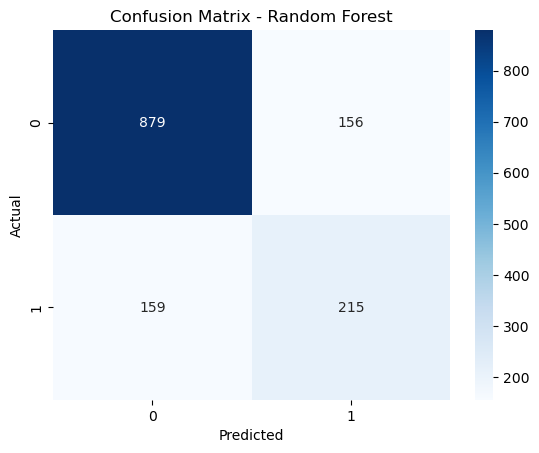

In [29]:
plt.figure()

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(r"C:\Users\SHREYASH\DSBDA\Project\Churn Prediciton")

plt.show()

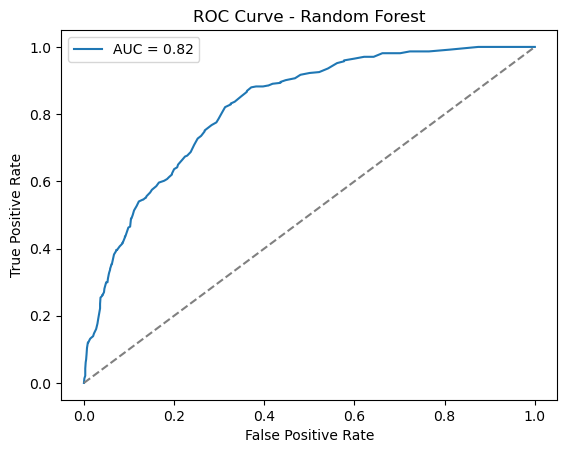

In [30]:
plt.figure()

y_prob_best = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_best)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob_best):.2f}")
plt.plot([0, 1], [0, 1], '--', color='gray')

plt.title(f"ROC Curve - {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.savefig(r"C:\Users\SHREYASH\DSBDA\Project\Churn Prediciton")

plt.show()

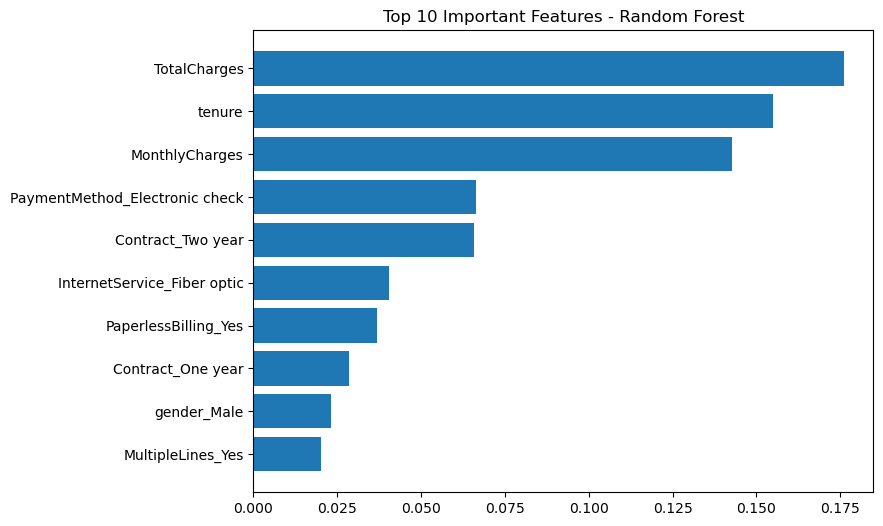

In [31]:
if best_model_name == "Random Forest":

    importances = best_model.feature_importances_

    indices = np.argsort(importances)[-10:]

    plt.figure(figsize=(8, 6))

    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [X.columns[i] for i in indices])

    plt.title(f"Top 10 Important Features - {best_model_name}")

    plt.savefig(r"C:\Users\SHREYASH\DSBDA\Project\Churn Prediciton")

    plt.show()

else:
    print("\nFeature importance plot skipped (not available for Logistic Regression).")